# EDA — Cartera 2023

Análisis exploratorio de la cartera de clientes (`CARTERA 2023 (P1).csv`), a partir del `df` limpio que genera `Actividad_Limpieza.ipynb` y que se hereda en la primera celda.

Primero se analiza cada variable por separado (univariado); después, las relaciones entre variables, con foco en `mora_historica` (bivariado); al final se resumen las conclusiones. En los gráficos el azul es el dato normal y el naranja marca énfasis (registros flagueados/imputados o una segunda serie).

In [1]:
%%capture
# Carga del df limpio: se ejecuta el notebook de limpieza (mismo directorio) y se hereda su `df`.
# %%capture oculta los outputs del notebook de limpieza para no repetirlos acá.
%run Actividad_Limpieza.ipynb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import chi2_contingency, kruskal
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# ---- Estilo de los gráficos: una paleta validada (daltonismo + contraste) y tintas recesivas
SURF, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE = "#2a78d6", "#eb6834"                      # azul = serie principal, naranja = énfasis
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]   # rampa secuencial
DIV = LinearSegmentedColormap.from_list("div", ["#184f95", "#5598e7", "#f0efec", "#e66767", "#b02f2f"])
CMAP_SEQ = LinearSegmentedColormap.from_list("seq", SEQ)

plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "text.color": INK, "font.size": 9.5, "axes.labelsize": 9.5,
    "legend.frameon": False, "figure.dpi": 100, "savefig.dpi": 100,
})

def tit(ax, titulo, sub=None):
    """Título a la izquierda + subtítulo chico con el dato clave."""
    ax.set_title(titulo, loc="left", fontsize=10.5, fontweight="semibold", color=INK, pad=20 if sub else 8)
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=8.5, color=INK2, va="bottom")

def fmt_pesos(x, _=None):
    if abs(x) >= 1e6: return f"{x/1e6:.1f}M".replace(".0M", "M")
    if abs(x) >= 1e3: return f"{x/1e3:.0f}k"
    return f"{x:.0f}"

def hist(ax, x, bins=40, color=BLUE, **kw):
    ax.hist(x, bins=bins, color=color, edgecolor=SURF, linewidth=0.6, **kw)

def logbins(x, n=40):
    x = x[x > 0]
    return np.geomspace(x.min(), x.max(), n)

def etiquetas_barras(ax, barras, fmt="{:.1f}%", horizontal=False):
    for b in barras:
        v = b.get_width() if horizontal else b.get_height()
        if horizontal:
            ax.text(v, b.get_y() + b.get_height()/2, "  " + fmt.format(v), va="center", fontsize=8.5, color=INK2)
        else:
            ax.text(b.get_x() + b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontsize=8.5, color=INK2)

print(f"df limpio: {df.shape[0]:,} filas x {df.shape[1]} columnas")

df limpio: 6,800 filas x 44 columnas


## 1. Panorama

Antes de analizar las variables se cuenta cuántos registros intervino la limpieza (flags), para saber qué parte de la base es dato observado y cuál fue corregido o imputado.

In [3]:
flags = [c for c in df.columns if c.startswith("flag_")]
resumen_flags = pd.DataFrame({"casos": df[flags].sum(), "% de la base": (df[flags].mean() * 100).round(1)})
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
resumen_flags

Filas: 6,800 | Columnas: 44


,casos,% de la base
flag_antig_inconsistente,198,2.9
flag_ingreso_inconsistente,22,0.3
flag_ingreso_imputado,1299,19.1
flag_score_faltante,530,7.8
flag_antig_imputada,1332,19.6
flag_tipo_empleo_imputado,320,4.7


La base tiene 6.800 clientes únicos (se eliminaron 40 ids duplicados). Las intervenciones más grandes son los faltantes: ingreso (1.299, 19,1%) y antigüedad laboral (1.332, 19,6%) se imputaron, 320 tipos de empleo (4,7%) se asignaron como Informal y los 530 scores faltantes (7,8%) se dejaron sin imputar. Los errores de dato son pocos: 22 ingresos con un cero de más (0,3%) y 198 antigüedades inconsistentes con la edad (2,9%), que solo se marcaron.

Como ingreso y antigüedad tienen aproximadamente 1 de cada 5 valores modelados, esto se tiene en cuenta al interpretar los resultados que los involucran.

## 2. Análisis univariado

Se estudia cada variable por separado: faltantes, cantidad de valores únicos (para distinguir continuas de discretas), centro (media vs. mediana), asimetría y valores extremos. En las variables monetarias los outliers por IQR se calculan en escala original y en escala logarítmica, porque los montos suelen ser lognormales y el criterio en escala original marca como extremos a muchos valores que son normales.

In [4]:
num = ["edad", "ingreso_imputado", "antiguedad_imputada", "score_buro", "deuda_actual", "consumo_tarjeta_mensual",
       "saldo_promedio", "limite_tarjeta", "monto_prestamo_solicitado", "cant_productos",
       "cant_consultas_recientes", "cant_atrasos_12m"]
monetarias = ["ingreso_imputado", "deuda_actual", "consumo_tarjeta_mensual", "saldo_promedio",
              "limite_tarjeta", "monto_prestamo_solicitado"]

def outliers_iqr(x, log=False):
    x = x.dropna()
    if log: x = np.log(x[x > 0])
    q1, q3 = x.quantile([.25, .75]); k = q3 - q1
    return int(((x < q1 - 1.5*k) | (x > q3 + 1.5*k)).sum())

filas = []
for c in num:
    x = df[c]
    filas.append({
        "variable": c, "faltantes": int(x.isna().sum()), "únicos": x.nunique(), "moda": x.mode().iloc[0],
        "media": x.mean(), "mediana": x.median(), "desvío": x.std(), "mín": x.min(), "máx": x.max(),
        "asimetría": x.skew(),
        "outliers IQR": outliers_iqr(x),
        "outliers IQR (log)": outliers_iqr(x, log=True) if c in monetarias else np.nan,
        "tipo": "discreta" if x.nunique() <= 15 else "continua"})
tabla_resumen = pd.DataFrame(filas).set_index("variable").round(2)
tabla_resumen

,faltantes,únicos,moda,media,mediana,desvío,mín,máx,asimetría,outliers IQR,outliers IQR (log),tipo
variable,,,,,,,,,,,,
edad,0,61,18.0,41.09,41.0,12.62,18.0,78.0,0.18,21,NaN,continua
ingreso_imputado,0,2772,90000.0,633708.07,531000.0,435265.90,90000.0,3881000.0,1.62,253,2.0,continua
antiguedad_imputada,0,355,0.0,9.65,9.5,5.10,0.0,28.0,0.21,19,NaN,continua
score_buro,530,385,662.0,664.91,665.0,71.91,389.0,850.0,-0.05,20,NaN,continua
deuda_actual,0,527,86000.0,145515.59,120000.0,103423.85,0.0,951000.0,1.75,259,86.0,continua
consumo_tarjeta_mensual,0,722,5000.0,191590.44,147000.0,162397.37,5000.0,1672000.0,2.08,331,135.0,continua
saldo_promedio,0,1163,0.0,352280.88,269000.0,308159.53,0.0,2779000.0,2.03,325,100.0,continua
limite_tarjeta,0,2189,328000.0,952219.41,755500.0,731966.12,73000.0,7249000.0,1.89,296,16.0,continua
monto_prestamo_solicitado,0,4171,832000.0,2985289.71,2257000.0,2510232.16,143000.0,24840000.0,2.13,328,15.0,continua


Las variables monetarias tienen asimetría entre 1,62 y 2,13, con la media muy por encima de la mediana (ingreso: 633.708 vs. 531.000). Edad (0,18), antigüedad (0,21) y score (−0,05) son casi simétricas. Cantidad de productos, consultas y atrasos tienen entre 10 y 12 valores únicos, por lo que se tratan como discretas.

Los outliers dependen de la escala. En escala original cada variable monetaria marca entre 253 y 331 clientes (4-5% de la base); en escala logarítmica quedan 2 para ingreso, 15-16 para préstamo y límite, y 86-135 para deuda, consumo y saldo. Casi todos esos valores extremos eran la cola natural de una distribución lognormal y no datos anómalos, por lo que no se elimina ningún registro. Para `cant_atrasos_12m` el criterio no aplica: más del 60% son ceros, el IQR es 0 y cualquier cliente con un atraso queda marcado.

Variables categóricas y variable objetivo: se mira la distribución de frecuencias para detectar categorías dominantes o casi vacías que haya que agrupar.

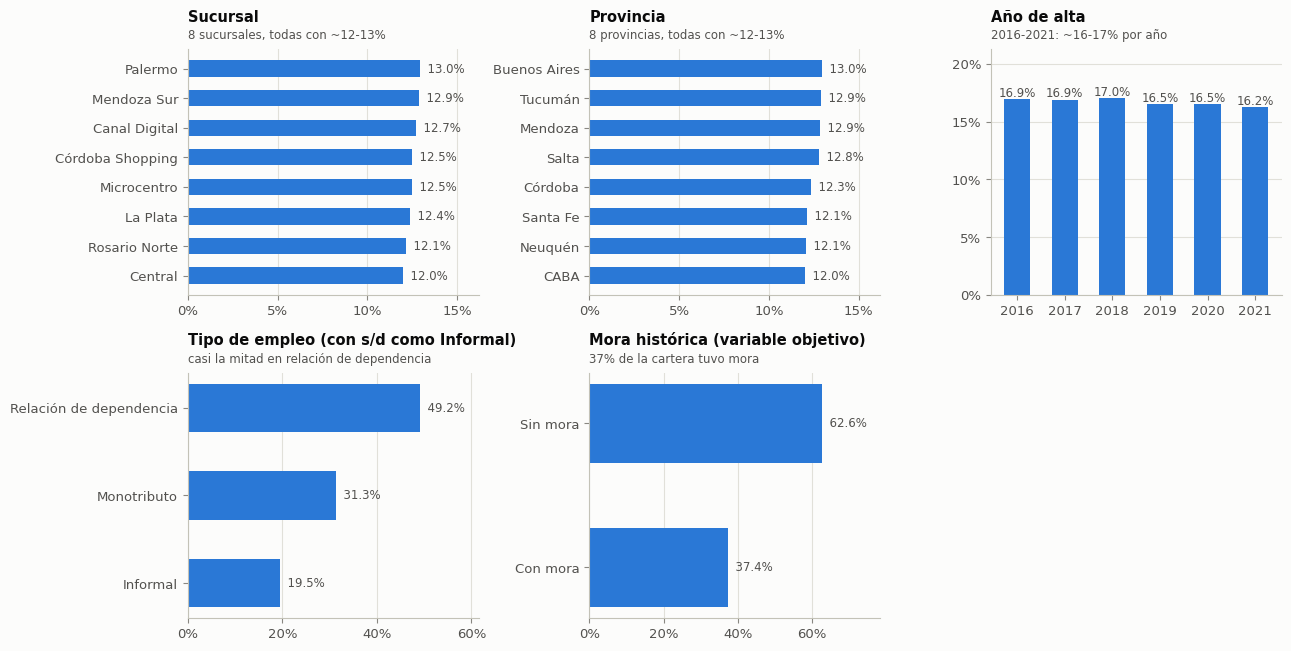

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
ax = axes.ravel()

def barras_cat(a, serie, titulo, sub, orden=None, horizontal=True):
    p = serie.value_counts(normalize=True) * 100
    p = p.reindex(orden) if orden is not None else p.sort_values()
    if horizontal:
        b = a.barh(p.index.astype(str), p.values, color=BLUE, height=0.55)
        etiquetas_barras(a, b, horizontal=True); a.grid(axis="y", visible=False); a.grid(axis="x")
        a.set_xlim(0, p.max() * 1.25); a.xaxis.set_major_locator(mtick.MaxNLocator(5, steps=[1, 2, 5, 10]))
        a.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    else:
        b = a.bar(p.index.astype(str), p.values, color=BLUE, width=0.55)
        etiquetas_barras(a, b); a.set_ylim(0, p.max() * 1.25); a.yaxis.set_major_locator(mtick.MaxNLocator(5, steps=[1, 2, 5, 10]))
        a.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    tit(a, titulo, sub)

barras_cat(ax[0], df["sucursal"], "Sucursal", f"{df.sucursal.nunique()} sucursales, todas con ~12-13%")
barras_cat(ax[1], df["provincia"], "Provincia", f"{df.provincia.nunique()} provincias, todas con ~12-13%")
barras_cat(ax[2], df["anio_alta"], "Año de alta", "2016-2021: ~16-17% por año",
           orden=sorted(df.anio_alta.unique()), horizontal=False)
barras_cat(ax[3], df["tipo_empleo_imputado"], "Tipo de empleo (con s/d como Informal)", "casi la mitad en relación de dependencia")
barras_cat(ax[4], df["mora_historica"].map({0: "Sin mora", 1: "Con mora"}), "Mora histórica (variable objetivo)",
           "37% de la cartera tuvo mora")
ax[5].axis("off")
plt.tight_layout(); plt.show()

Sucursal y provincia tienen 8 categorías cada una, todas entre 12% y 13%, y los años de alta se reparten parejo entre 2016 y 2021 (16-17% cada uno): no hay categorías raras que agrupar. En tipo de empleo, 49,2% es relación de dependencia, 31,3% monotributo y 19,5% informal (incluye los 320 sin dato asignados como Informal; los informales originales son ~14,8%).

El 37,4% de la cartera tuvo mora. El desbalance es moderado y no requiere remuestreo.

Edad, antigüedad laboral y score: son las variables que en la tabla resultaron casi simétricas.

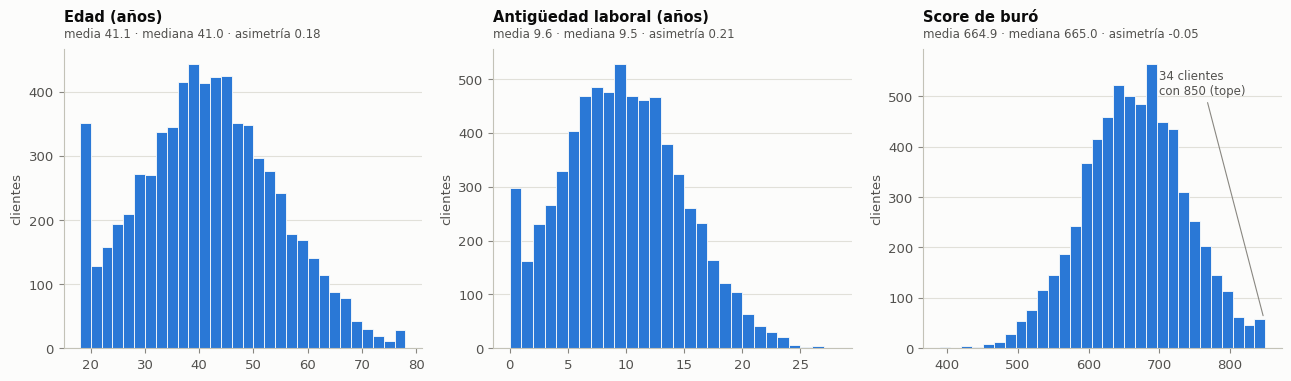

Score: n=6270 | mín 389 | máx 850 | exactamente 850: 34


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for a, c, t, bins in [(axes[0], "edad", "Edad (años)", 30),
                      (axes[1], "antiguedad_imputada", "Antigüedad laboral (años)", 28),
                      (axes[2], "score_buro", "Score de buró", 30)]:
    hist(a, df[c].dropna(), bins=bins)
    tit(a, t, f"media {df[c].mean():.1f} · mediana {df[c].median():.1f} · asimetría {df[c].skew():.2f}")
    a.set_ylabel("clientes"); a.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
n850 = int((df.score_buro == 850).sum())
axes[2].annotate(f"{n850} clientes\ncon 850 (tope)", xy=(848, axes[2].get_ylim()[1] * 0.10), xytext=(700, axes[2].get_ylim()[1] * 0.85),
                 fontsize=8.5, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
plt.tight_layout(); plt.show()
print(f"Score: n={df.score_buro.notna().sum()} | mín {df.score_buro.min():.0f} | máx {df.score_buro.max():.0f} | exactamente 850: {n850}")

La edad va de 18 a 78 años (media 41,1; mediana 41), con una leve acumulación en los 18-19 años. La antigüedad tiene media 9,6, mediana 9,5 y máximo 28 años; como el 19,6% está imputado por regresión, su forma exacta depende en parte del modelo. El score tiene forma de campana (media 664,9; mediana 665) entre 389 y 850, y hay 34 clientes con exactamente 850, que es el tope de la escala, por lo que esos valores están censurados. Ninguna de las tres necesita transformación.

Ingreso: se compara su distribución en escala original y en escala logarítmica.

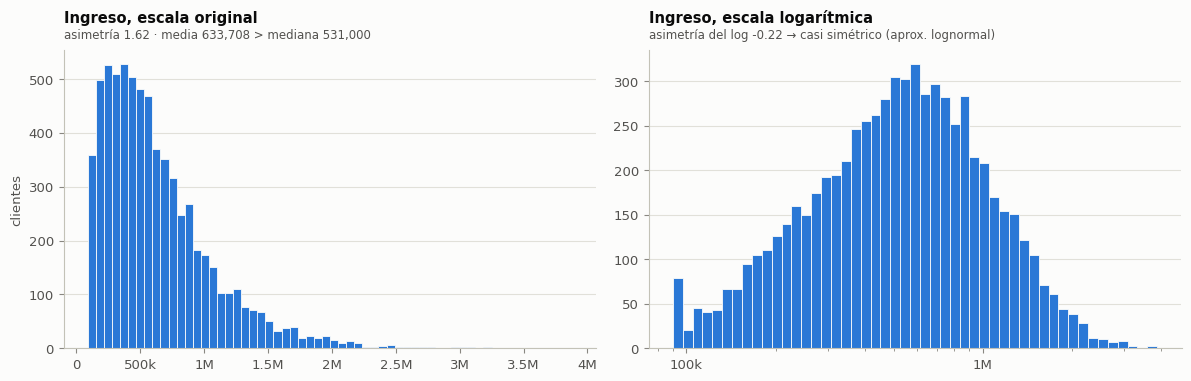

Asimetría raw: 1.62 | Asimetría log: -0.22
Outliers IQR en raw: 253 | en log: 2


In [7]:
x = df["ingreso_imputado"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.9))
hist(axes[0], x, bins=60)
tit(axes[0], "Ingreso, escala original", f"asimetría {x.skew():.2f} · media {x.mean():,.0f} > mediana {x.median():,.0f}")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos)); axes[0].set_ylabel("clientes")

hist(axes[1], x, bins=logbins(x, 50))
axes[1].set_xscale("log"); axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos))
axes[1].xaxis.set_minor_formatter(mtick.NullFormatter())
tit(axes[1], "Ingreso, escala logarítmica", f"asimetría del log {np.log(x).skew():.2f} → casi simétrico (aprox. lognormal)")
plt.tight_layout(); plt.show()
print("Asimetría raw:", round(x.skew(), 2), "| Asimetría log:", round(np.log(x).skew(), 2))
print("Outliers IQR en raw:", outliers_iqr(x), "| en log:", outliers_iqr(x, log=True))

En escala original el ingreso es muy asimétrico a la derecha (1,62): la media queda por encima de la mediana y la cola llega a 3,9 millones. En escala logarítmica la asimetría baja a −0,22 y la distribución es casi simétrica, es decir que el ingreso se comporta aproximadamente como una lognormal. Por eso el criterio IQR marca 253 outliers en escala original y solo 2 en escala logarítmica: los 253 son la cola derecha natural.

La asimetría levemente negativa del logaritmo se debe al piso de 90.000 usado al imputar, por lo que la lognormal es una buena aproximación pero no exacta.

Control de calidad del ingreso: se verifica que los 22 registros con error de unidad se distingan del resto y que la imputación de 1.299 valores no haya deformado la distribución.

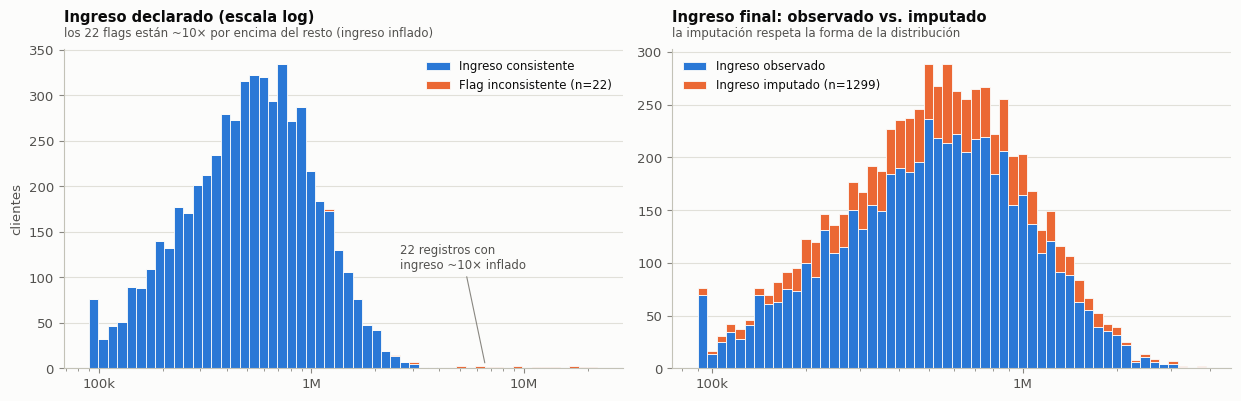

Imputados que quedaron clavados en el piso de 90.000: 4
Ratio limite/ingreso de los flagueados (mediana): 0.2 | del resto: 1.49


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.1))

# Panel A: ingreso declarado, con los 22 registros con error de unidad resaltados
d = df["ingreso_declarado"].dropna()
malos = df.loc[df.flag_ingreso_inconsistente, "ingreso_declarado"]
bins = logbins(d, 55)
axes[0].hist([d[~d.index.isin(malos.index)], malos], bins=bins, stacked=True, color=[BLUE, ORANGE],
             edgecolor=SURF, linewidth=0.6, label=["Ingreso consistente", f"Flag inconsistente (n={len(malos)})"])
axes[0].set_xscale("log"); axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos))
axes[0].xaxis.set_minor_formatter(mtick.NullFormatter())
tit(axes[0], "Ingreso declarado (escala log)", "los 22 flags están ~10× por encima del resto (ingreso inflado)")
axes[0].legend(loc="upper right", fontsize=8.5); axes[0].set_ylabel("clientes")
axes[0].annotate(f"{len(malos)} registros con\ningreso ~10× inflado", xy=(malos.median(), 3), xytext=(2.6e6, 110),
                 fontsize=8.5, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))

# Panel B: ingreso final; los imputados se apilan
xi = df["ingreso_imputado"]
axes[1].hist([xi[~df.flag_ingreso_imputado], xi[df.flag_ingreso_imputado]], bins=logbins(xi, 55), stacked=True,
             color=[BLUE, ORANGE], edgecolor=SURF, linewidth=0.6,
             label=["Ingreso observado", f"Ingreso imputado (n={int(df.flag_ingreso_imputado.sum())})"])
axes[1].set_xscale("log"); axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos))
axes[1].xaxis.set_minor_formatter(mtick.NullFormatter())
tit(axes[1], "Ingreso final: observado vs. imputado", "la imputación respeta la forma de la distribución")
axes[1].legend(loc="upper left", fontsize=8.5)
plt.tight_layout(); plt.show()

piso = int((df.loc[df.flag_ingreso_imputado, "ingreso_imputado"] == 90_000).sum())
print(f"Imputados que quedaron clavados en el piso de 90.000: {piso}")
print("Ratio limite/ingreso de los flagueados (mediana):", round(df.loc[df.flag_ingreso_inconsistente, 'ratio_limite_ingreso'].median(), 1),
      "| del resto:", round(df.loc[~df.flag_ingreso_inconsistente, 'ratio_limite_ingreso'].median(), 2))

Los 22 registros flagueados tienen un ingreso declarado con mediana de 6,6 millones (hasta 22 millones) y un ratio límite/ingreso mediano de 0,2, contra 1,49 del resto: el ingreso está inflado unas 10 veces, lo que confirma el error de carga que se corrigió dividiendo por 10 (algún caso, como el de 1,2 millones, cae dentro del rango normal y solo se detecta por el ratio).

Los valores imputados se reparten en todo el rango con la misma forma que los observados y solo 4 quedaron pegados al piso de 90.000. Al ser predicciones sin ruido, es esperable que subestimen algo la dispersión real del ingreso.

Resto de las variables monetarias: histograma en escala original (arriba) y logarítmica (abajo, sin los ceros, porque el logaritmo de cero no está definido).

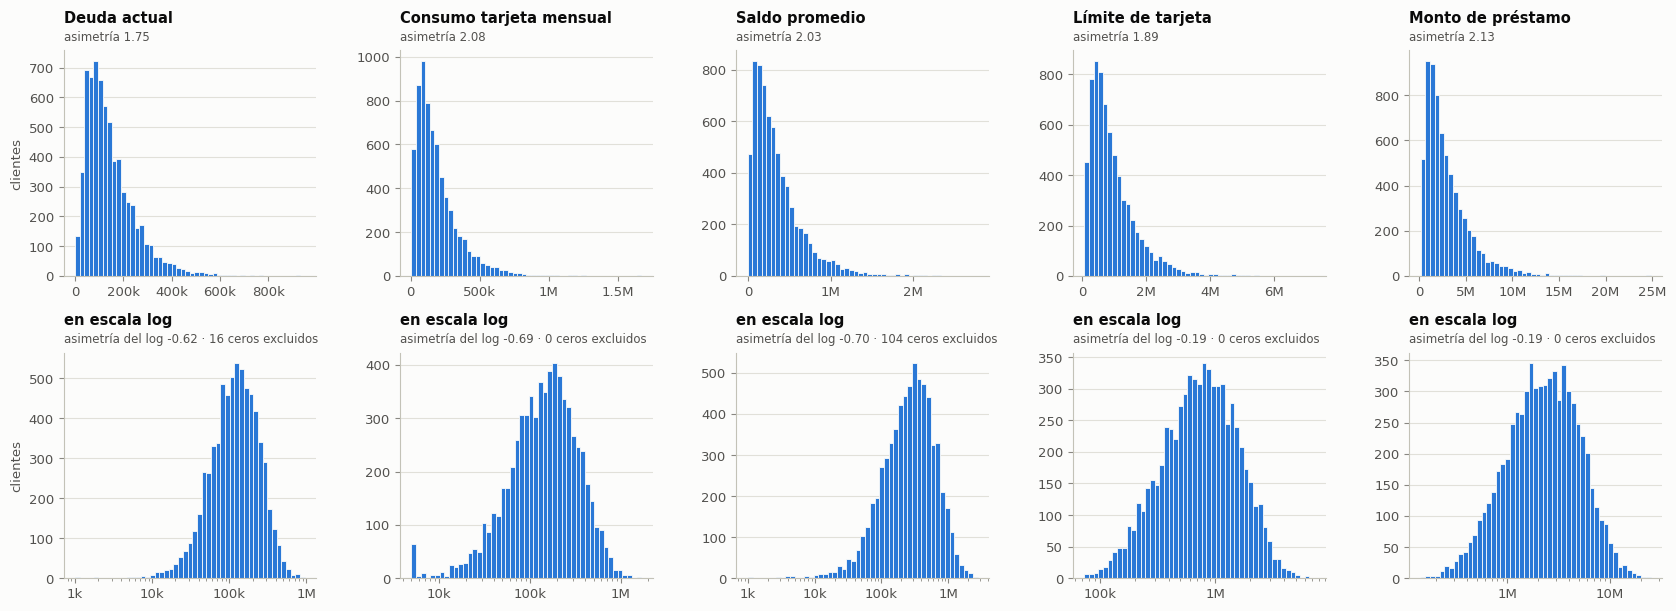

deuda_actual                 ceros:   16 | outliers IQR raw:  259 | outliers IQR log:   86
consumo_tarjeta_mensual      ceros:    0 | outliers IQR raw:  331 | outliers IQR log:  135
saldo_promedio               ceros:  104 | outliers IQR raw:  325 | outliers IQR log:  100
limite_tarjeta               ceros:    0 | outliers IQR raw:  296 | outliers IQR log:   16
monto_prestamo_solicitado    ceros:    0 | outliers IQR raw:  328 | outliers IQR log:   15


In [9]:
otras = ["deuda_actual", "consumo_tarjeta_mensual", "saldo_promedio", "limite_tarjeta", "monto_prestamo_solicitado"]
nombres = ["Deuda actual", "Consumo tarjeta mensual", "Saldo promedio", "Límite de tarjeta", "Monto de préstamo"]
fig, axes = plt.subplots(2, 5, figsize=(17, 6.2))
for j, (c, n) in enumerate(zip(otras, nombres)):
    x = df[c]; xp = x[x > 0]
    hist(axes[0, j], x, bins=50)
    tit(axes[0, j], n, f"asimetría {x.skew():.2f}")
    axes[0, j].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos))
    hist(axes[1, j], xp, bins=logbins(xp, 50)); axes[1, j].set_xscale("log")
    axes[1, j].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos)); axes[1, j].xaxis.set_minor_formatter(mtick.NullFormatter())
    tit(axes[1, j], "en escala log", f"asimetría del log {np.log(xp).skew():.2f} · {int((x <= 0).sum())} ceros excluidos")
axes[0, 0].set_ylabel("clientes"); axes[1, 0].set_ylabel("clientes")
plt.tight_layout(); plt.show()
for c in otras:
    x = df[c]
    print(f"{c:28s} ceros: {(x == 0).sum():4d} | outliers IQR raw: {outliers_iqr(x):4d} | outliers IQR log: {outliers_iqr(x, log=True):4d}")

Las cinco son aproximadamente lognormales: la asimetría va de 1,75 a 2,13 en escala original y baja a valores entre −0,19 y −0,70 con logaritmo. Límite y préstamo son las más limpias (−0,19). Deuda, consumo y saldo (−0,62 a −0,70) tienen una cola de valores bajos que explica los outliers que sobreviven en escala logarítmica.

Hay 16 clientes con deuda 0 y 104 con saldo promedio 0 (1,5% de la base): son valores reales y no faltantes, pero impiden aplicar el logaritmo directamente. La moda del consumo (5.000) coincide con su mínimo, lo que sugiere un piso en los registros.

Variables de conteo (productos, consultas y atrasos): al ser discretas se grafican como barras, agrupando las colas raras en la última categoría.

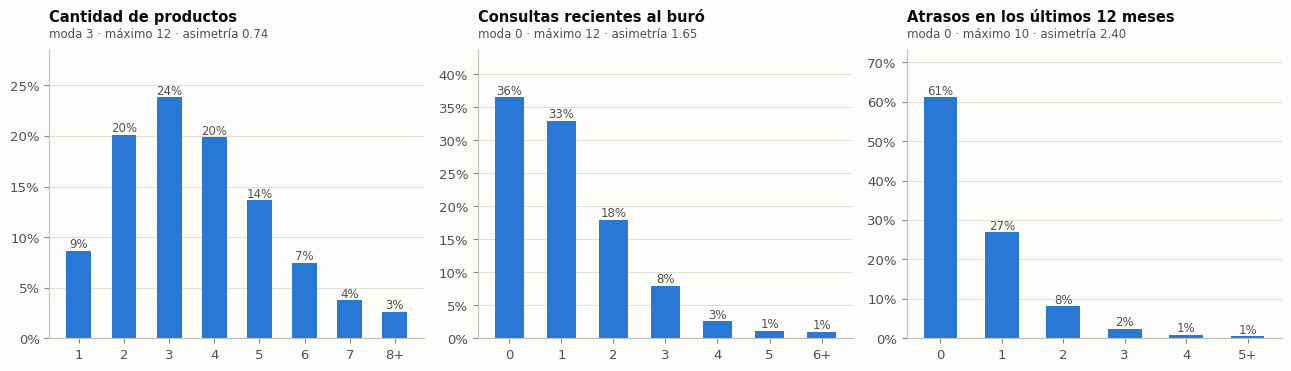

Cantidad de productos: mediana 3.0 | Consultas = 0: 36.5% | Atrasos = 0: 61.1%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for a, c, t, tope in [(axes[0], "cant_productos", "Cantidad de productos", 8),
                      (axes[1], "cant_consultas_recientes", "Consultas recientes al buró", 6),
                      (axes[2], "cant_atrasos_12m", "Atrasos en los últimos 12 meses", 5)]:
    v = df[c].clip(upper=tope)
    p = v.value_counts(normalize=True).sort_index() * 100
    etiqueta = [str(i) if i < tope else f"{tope}+" for i in p.index]
    b = a.bar(etiqueta, p.values, color=BLUE, width=0.55)
    etiquetas_barras(a, b, fmt="{:.0f}%")
    a.set_ylim(0, p.max() * 1.2); a.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    tit(a, t, f"moda {df[c].mode().iloc[0]} · máximo {df[c].max()} · asimetría {df[c].skew():.2f}")
plt.tight_layout(); plt.show()
print("Cantidad de productos: mediana", df.cant_productos.median(), "| Consultas = 0:", f"{(df.cant_consultas_recientes == 0).mean():.1%}",
      "| Atrasos = 0:", f"{(df.cant_atrasos_12m == 0).mean():.1%}")

La cantidad de productos se concentra entre 2 y 4 (moda 3, 24% de los clientes) y solo ~3% tiene 8 o más. El 36,5% no tuvo consultas recientes y el 33% tuvo una. El 61,1% no tuvo atrasos en los últimos 12 meses y el 27% tuvo uno.

Consultas y atrasos concentran casi toda su masa en valores chicos (asimetría 1,65 y 2,40), por lo que conviene tratarlos como categorías ordenadas (0, 1, 2, 3+) más que como numéricas continuas.

**Resumen del univariado.** Las variables monetarias son aproximadamente lognormales y sus outliers son la cola natural (se trabaja en escala logarítmica y no se elimina nada). El score está censurado en 850, saldo y deuda tienen ceros reales y los conteos se concentran en valores bajos. Sucursal, provincia y año de alta están balanceados. La mora afecta al 37,4% de la cartera.

## 3. Análisis bivariado

Se estudian las relaciones entre variables, con foco en qué se asocia con la mora. Se empieza por la matriz de correlación de Spearman, que se usa en lugar de Pearson porque casi todas las variables son asimétricas o discretas y Spearman mide relaciones monótonas sin depender de la forma de la distribución. Rojo indica correlación positiva, azul negativa y gris ausencia de relación.

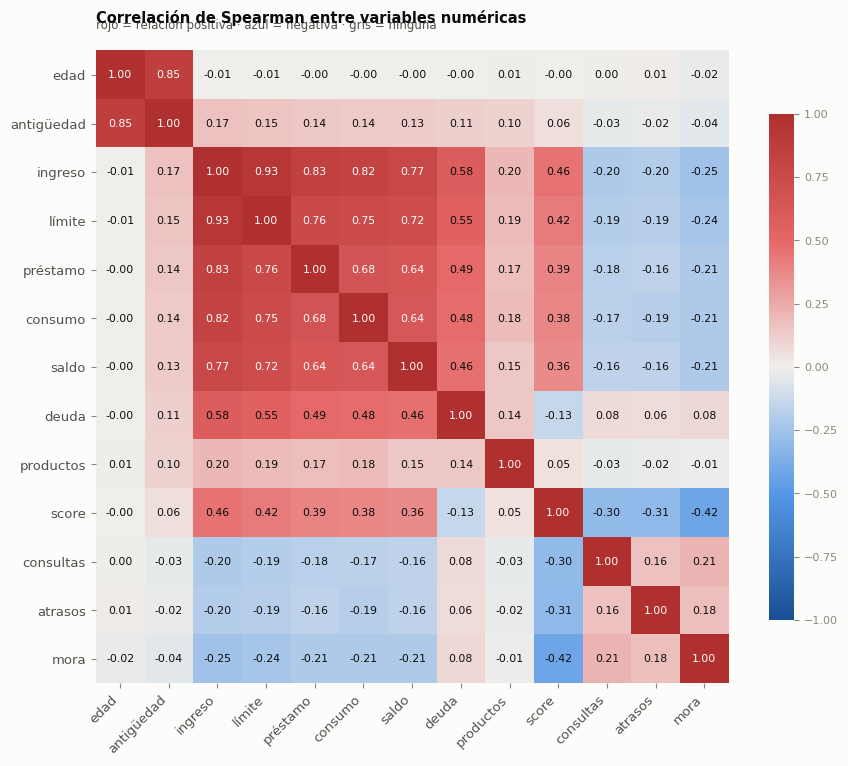

ingreso_imputado           limite_tarjeta               0.93
edad                       antiguedad_imputada          0.85
ingreso_imputado           monto_prestamo_solicitado    0.83
                           consumo_tarjeta_mensual      0.82
                           saldo_promedio               0.77
limite_tarjeta             monto_prestamo_solicitado    0.76
                           consumo_tarjeta_mensual      0.75
                           saldo_promedio               0.72
monto_prestamo_solicitado  consumo_tarjeta_mensual      0.68
                           saldo_promedio               0.64
consumo_tarjeta_mensual    saldo_promedio               0.64
ingreso_imputado           deuda_actual                 0.58
limite_tarjeta             deuda_actual                 0.55
monto_prestamo_solicitado  deuda_actual                 0.49
Name: spearman, dtype: float64

In [11]:
cols_corr = ["edad", "antiguedad_imputada", "ingreso_imputado", "limite_tarjeta", "monto_prestamo_solicitado",
             "consumo_tarjeta_mensual", "saldo_promedio", "deuda_actual", "cant_productos", "score_buro",
             "cant_consultas_recientes", "cant_atrasos_12m", "mora_historica"]
etiq = ["edad", "antigüedad", "ingreso", "límite", "préstamo", "consumo", "saldo", "deuda", "productos",
        "score", "consultas", "atrasos", "mora"]
corr = df[cols_corr].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.2, 7.6))
im = ax.imshow(corr.values, cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(etiq))); ax.set_xticklabels(etiq, rotation=45, ha="right")
ax.set_yticks(range(len(etiq))); ax.set_yticklabels(etiq)
ax.grid(False)
for s in ax.spines.values(): s.set_visible(False)
for i in range(len(etiq)):
    for j in range(len(etiq)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.8, color="white" if abs(v) > 0.6 else INK)
cb = plt.colorbar(im, ax=ax, shrink=0.8); cb.outline.set_visible(False); cb.ax.tick_params(colors=MUTED, labelsize=8)
tit(ax, "Correlación de Spearman entre variables numéricas", "rojo = relación positiva · azul = negativa · gris = ninguna")
plt.tight_layout(); plt.show()

# Los pares más fuertes (sin la diagonal)
par = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack().rename("spearman")
par = par.reindex(par.abs().sort_values(ascending=False).index)
par.head(14).round(2)

Ingreso, límite, préstamo, consumo y saldo están fuertemente correlacionados entre sí (0,64 a 0,93; el máximo es ingreso-límite): todas reflejan la escala económica del cliente. Parte de esa relación es artificial, porque el ingreso está imputado en el 19% de los casos a partir de límite, préstamo y consumo. Edad y antigüedad se correlacionan en 0,85 y la edad no se relaciona con nada más (≈ 0).

El score se asocia positivamente con ingreso (0,46) y límite (0,42) y negativamente con consultas (−0,30) y atrasos (−0,31); con la deuda absoluta la correlación es de solo −0,13, aunque más adelante se ve que el ratio deuda/ingreso sí es muy informativo. La mora se relaciona sobre todo con el score (−0,42), luego con ingreso (−0,25) y límite (−0,24), y con consultas (0,21) y atrasos (0,18); con cantidad de productos es ≈ 0 (−0,01).

La matriz no detecta relaciones no lineales ni ratios, por lo que se profundiza en los siguientes gráficos.

Edad vs. antigüedad laboral, marcando los 198 casos flagueados por haber empezado a trabajar antes de los 16 años.

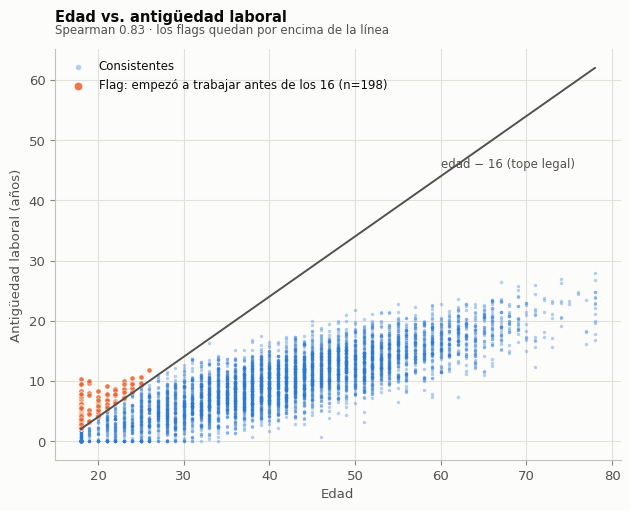

In [12]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ok = ~df.flag_antig_imputada & ~df.flag_antig_inconsistente
sc = df[ok]
ax.scatter(sc.edad, sc.antiguedad_laboral, s=6, color=BLUE, alpha=0.35, linewidths=0, label="Consistentes")
mal = df[df.flag_antig_inconsistente]
ax.scatter(mal.edad, mal.antiguedad_laboral, s=14, color=ORANGE, alpha=0.9, linewidths=0.4, edgecolors=SURF,
           label=f"Flag: empezó a trabajar antes de los 16 (n={len(mal)})")
xs = np.array([18, 78]); ax.plot(xs, xs - 16, color=INK2, lw=1.4)
ax.text(60, 60 - 16 + 1.5, "edad − 16 (tope legal)", fontsize=8.5, color=INK2, rotation=0)
ax.set_xlabel("Edad"); ax.set_ylabel("Antigüedad laboral (años)"); ax.grid(axis="x")
ax.legend(loc="upper left", fontsize=8.5, markerscale=1.6)
rho = df[["edad", "antiguedad_laboral"]].corr(method="spearman").iloc[0, 1]
tit(ax, "Edad vs. antigüedad laboral", f"Spearman {rho:.2f} · los flags quedan por encima de la línea")
plt.tight_layout(); plt.show()

La antigüedad crece con la edad (Spearman 0,83 en los datos observados) pero con mucha dispersión, como es esperable. Los 198 casos flagueados quedan todos por encima de la línea que marca el máximo posible (edad − 16) y se concentran en los más jóvenes (aprox. 18 a 26 años).

Es un problema acotado (2,9% de la base). Como no se sabe si el error está en la edad o en la antigüedad, corregirlo a ciegas agregaría ruido, y por eso se decidió solo marcarlos.

Ratios respecto del ingreso: la correlación de 0,93 entre ingreso y límite sugiere que el límite se define a partir del ingreso. Para comprobarlo se calculan los cocientes solo donde el ingreso es observado (5.501 clientes), para no mezclar valores imputados. El ratio deuda/ingreso se llama `dti_obs` para distinguirlo de la columna `dti` del notebook de limpieza, que usa el ingreso imputado.

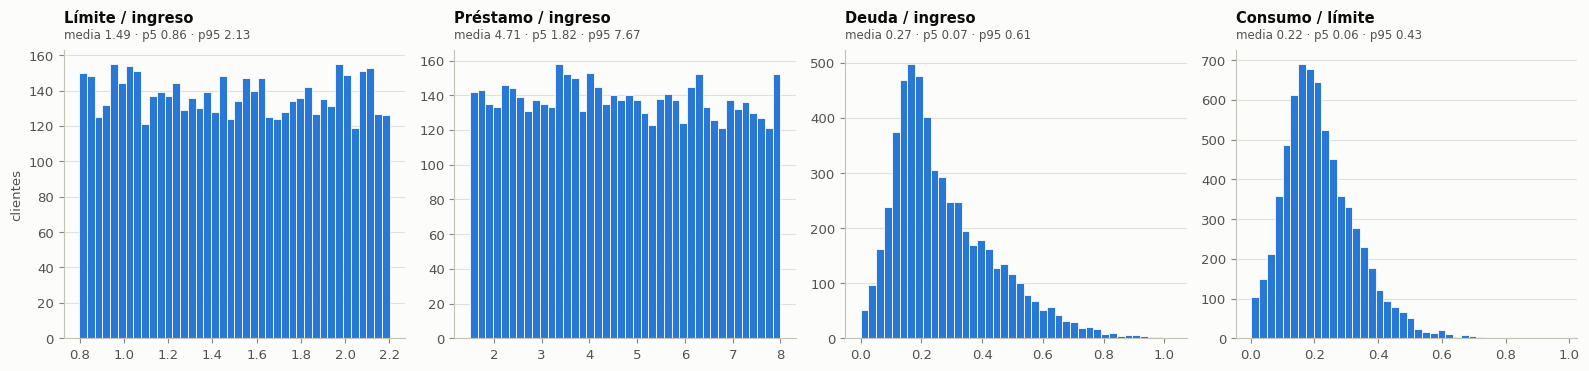

,lim_ing,pres_ing,dti_obs,cons_limite,saldo_ing
count,5501.00,5501.00,5501.00,6800.00,5501.00
mean,1.49,4.71,0.27,0.22,0.55
std,0.41,1.87,0.17,0.11,0.25
min,0.80,1.50,0.00,0.00,0.00
5%,0.86,1.82,0.07,0.06,0.13
50%,1.49,4.66,0.23,0.20,0.55
95%,2.13,7.67,0.61,0.43,0.96
max,2.20,8.00,1.02,0.98,1.39


In [13]:
oi = df["ingreso_corregido"].notna()          # ratios solo donde el ingreso es observado (no imputado)
df["dti_obs"] = np.where(oi, df.deuda_actual / df.ingreso_corregido, np.nan)          # deuda / ingreso
df["cons_limite"] = df.consumo_tarjeta_mensual / df.limite_tarjeta
df["saldo_ing"] = np.where(oi, df.saldo_promedio / df.ingreso_corregido, np.nan)
df["pres_ing"] = np.where(oi, df.monto_prestamo_solicitado / df.ingreso_corregido, np.nan)
df["lim_ing"] = np.where(oi, df.limite_tarjeta / df.ingreso_corregido, np.nan)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for a, c, t in [(axes[0], "lim_ing", "Límite / ingreso"), (axes[1], "pres_ing", "Préstamo / ingreso"),
                (axes[2], "dti_obs", "Deuda / ingreso"), (axes[3], "cons_limite", "Consumo / límite")]:
    x = df[c].dropna()
    hist(a, x, bins=40)
    tit(a, t, f"media {x.mean():.2f} · p5 {x.quantile(.05):.2f} · p95 {x.quantile(.95):.2f}")
axes[0].set_ylabel("clientes")
plt.tight_layout(); plt.show()
df[["lim_ing", "pres_ing", "dti_obs", "cons_limite", "saldo_ing"]].describe(percentiles=[.05, .5, .95]).round(2)

Límite/ingreso se ubica entre 0,80 y 2,20 y préstamo/ingreso entre 1,5 y 8,0, con distribución casi uniforme y bordes nítidos. Eso no ocurre de manera natural y sugiere una regla de asignación (el límite y el monto solicitable serían múltiplos acotados del ingreso), que además es lo que permitió detectar los 22 ingresos con error. Como consecuencia, los montos absolutos aportan poca información propia y los ratios son más informativos.

Deuda/ingreso tiene media 0,27, el 90% de los clientes entre 0,07 y 0,61 y máximo 1,02. Consumo/límite tiene media 0,22 y máximo 0,98, es decir que nadie supera su límite.

Qué explica el score de buró: se lo relaciona con deuda/ingreso (hexbin, porque con 5.000 puntos un scatter se satura) y con atrasos y consultas.

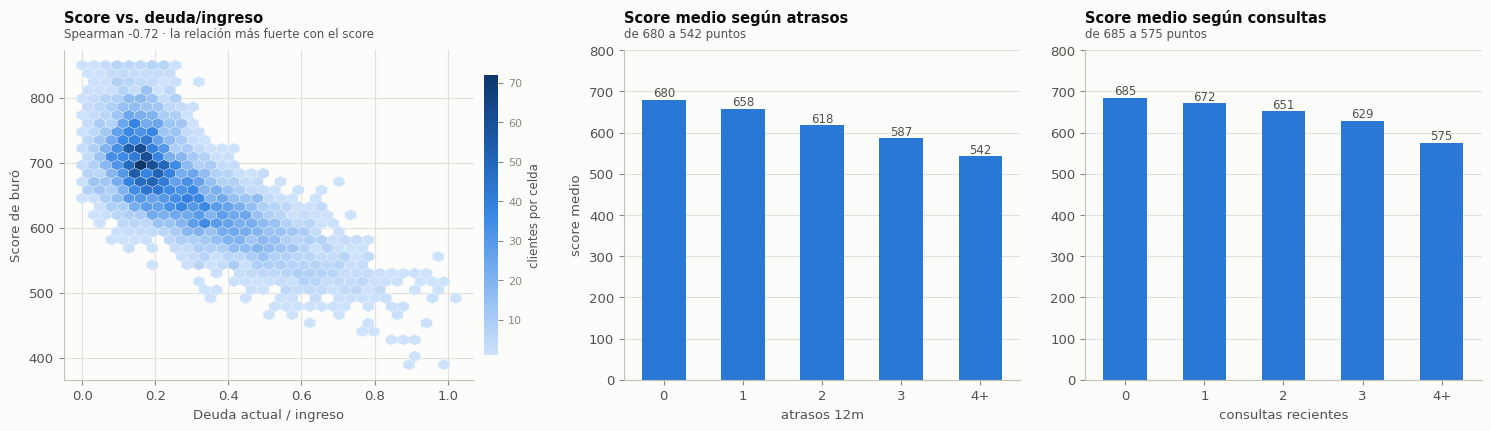

Spearman score-consultas: -0.3 | score-atrasos: -0.31 | score-ingreso: 0.46


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.25, 1, 1]})

# Score vs deuda/ingreso: hexbin (6.000 puntos se superponen en un scatter)
d = df.dropna(subset=["score_buro", "dti_obs"])
hb = axes[0].hexbin(d.dti_obs, d.score_buro, gridsize=32, cmap=CMAP_SEQ, mincnt=1, linewidths=0.2, edgecolors=SURF)
cb = plt.colorbar(hb, ax=axes[0], shrink=0.85, pad=0.02); cb.outline.set_visible(False)
cb.set_label("clientes por celda", fontsize=8.5, color=INK2); cb.ax.tick_params(colors=MUTED, labelsize=8)
axes[0].set_xlabel("Deuda actual / ingreso"); axes[0].set_ylabel("Score de buró"); axes[0].grid(axis="x")
rho_dti = d[["score_buro", "dti_obs"]].corr(method="spearman").iloc[0, 1]
tit(axes[0], "Score vs. deuda/ingreso", f"Spearman {rho_dti:.2f} · la relación más fuerte con el score")

for a, c, t, tope in [(axes[1], "cant_atrasos_12m", "Score medio según atrasos", 4),
                      (axes[2], "cant_consultas_recientes", "Score medio según consultas", 4)]:
    g = df.groupby(df[c].clip(upper=tope)).score_buro.mean()
    etiqueta = [str(i) if i < tope else f"{tope}+" for i in g.index]
    b = a.bar(etiqueta, g.values, color=BLUE, width=0.55)
    etiquetas_barras(a, b, fmt="{:.0f}")
    a.set_ylim(0, 800); a.set_xlabel("atrasos 12m" if "atrasos" in c else "consultas recientes")
    tit(a, t, f"de {g.iloc[0]:.0f} a {g.iloc[-1]:.0f} puntos")
axes[1].set_ylabel("score medio")
plt.tight_layout(); plt.show()
print("Spearman score-consultas:", round(df[["score_buro", "cant_consultas_recientes"]].corr(method="spearman").iloc[0, 1], 2),
      "| score-atrasos:", round(df[["score_buro", "cant_atrasos_12m"]].corr(method="spearman").iloc[0, 1], 2),
      "| score-ingreso:", round(df[["score_buro", "ingreso_imputado"]].corr(method="spearman").iloc[0, 1], 2))

Deuda/ingreso es el mejor predictor del score (Spearman −0,72): con deuda/ingreso bajo el score se concentra entre 650 y 750, y cerca de 1 baja a 400-500. La matriz mostraba solo −0,13 con la deuda absoluta, así que lo que importa es la deuda en relación al ingreso.

El score medio también cae con los atrasos (680 sin atrasos; 658, 618, 587 y 542 con 4 o más) y con las consultas (685 sin consultas; 672, 651, 629 y 575 con 4 o más). En conjunto, el score parece resumir el comportamiento crediticio: penaliza el endeudamiento relativo, los atrasos y las consultas recientes.

Ingreso y score según tipo de empleo (boxplots: la caja contiene el 50% central de los clientes y la línea negra es la mediana).

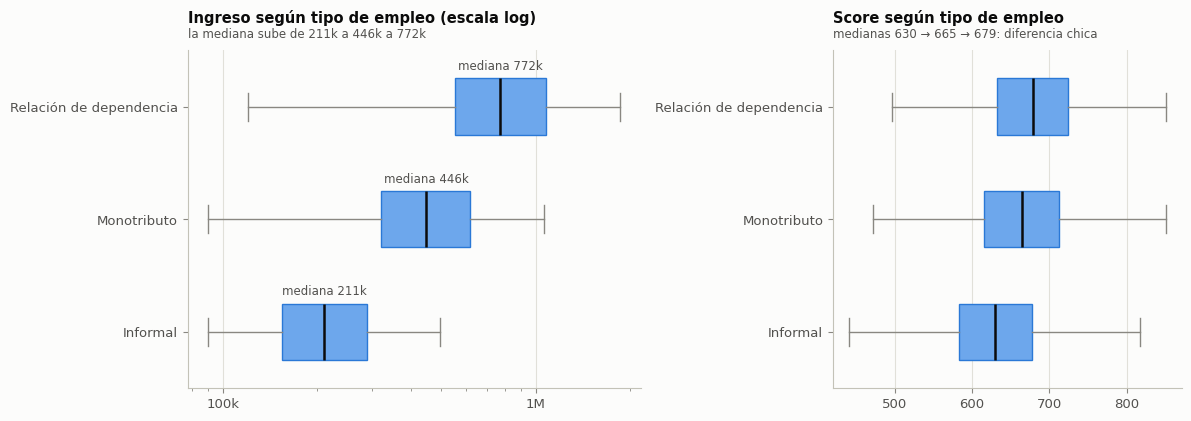

                         mediana ingreso  mediana score
Informal                        211000.0          630.0
Monotributo                     446000.0          665.0
Relación de dependencia         772000.0          679.0
Kruskal ingreso ~ tipo: p = 0.0 | Kruskal score ~ tipo: p = 0.0


In [15]:
orden = ["Informal", "Monotributo", "Relación de dependencia"]
grupos = [df.loc[df.tipo_empleo_imputado == t, "ingreso_imputado"] for t in orden]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), gridspec_kw={"width_ratios": [1.3, 1]})

bp = axes[0].boxplot(grupos, vert=False, patch_artist=True, widths=0.5, showfliers=False,
                     medianprops=dict(color=INK, lw=1.8), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
for p in bp["boxes"]: p.set(facecolor=SEQ[2], edgecolor=BLUE, lw=1)
axes[0].set_yticks([1, 2, 3]); axes[0].set_yticklabels(orden)
axes[0].set_xscale("log"); axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(fmt_pesos))
axes[0].xaxis.set_minor_formatter(mtick.NullFormatter())
axes[0].grid(axis="y", visible=False); axes[0].grid(axis="x")
for i, g in enumerate(grupos, 1):
    axes[0].text(g.median(), i + 0.33, f"mediana {fmt_pesos(g.median())}", ha="center", fontsize=8.5, color=INK2)
tit(axes[0], "Ingreso según tipo de empleo (escala log)", "la mediana sube de 211k a 446k a 772k")

# Score por tipo de empleo (mismo formato)
grupos_s = [df.loc[df.tipo_empleo_imputado == t, "score_buro"].dropna() for t in orden]
bp2 = axes[1].boxplot(grupos_s, vert=False, patch_artist=True, widths=0.5, showfliers=False,
                      medianprops=dict(color=INK, lw=1.8), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
for p in bp2["boxes"]: p.set(facecolor=SEQ[2], edgecolor=BLUE, lw=1)
axes[1].set_yticks([1, 2, 3]); axes[1].set_yticklabels(orden); axes[1].grid(axis="y", visible=False); axes[1].grid(axis="x")
tit(axes[1], "Score según tipo de empleo", "medianas 630 → 665 → 679: diferencia chica")
plt.tight_layout(); plt.show()

print(pd.DataFrame({"mediana ingreso": [g.median() for g in grupos], "mediana score": [g.median() for g in grupos_s]}, index=orden).round(0))
print("Kruskal ingreso ~ tipo: p =", kruskal(*grupos).pvalue, "| Kruskal score ~ tipo: p =", round(kruskal(*grupos_s).pvalue, 4))

El ingreso separa claramente a los tres grupos: medianas de 211.000 (informal), 446.000 (monotributo) y 772.000 (relación de dependencia), con cajas que casi no se superponen (Kruskal-Wallis, p < 0,001). El score también difiere (medianas de 630, 665 y 679) pero poco: es significativo por el tamaño de la muestra, aunque los rangos se superponen casi por completo. Esto indica que el score depende más del comportamiento crediticio que del ingreso o del tipo de empleo.

Los 320 clientes sin dato de empleo están asignados como Informal; como su perfil era indistinguible del de los informales, no debería alterar este resultado.

Tasa de mora según cada variable candidata (por categoría o, en variables continuas, por deciles u octiles). La línea gris es la mora promedio de la cartera (37,4%) y todos los ejes van de 0 a 100%.

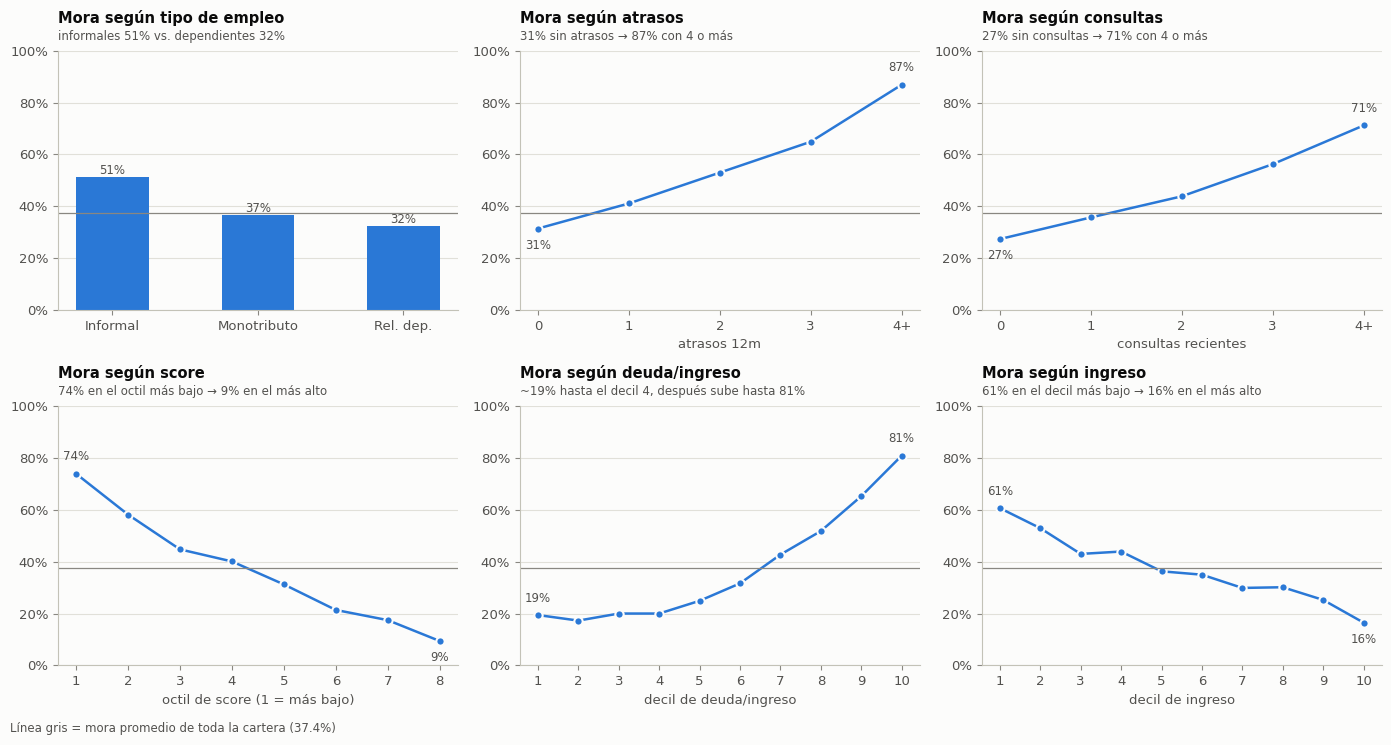

Tasa global de mora: 37.4 %
Tipo {'Informal': 51.1, 'Monotributo': 36.7, 'Relación de dependencia': 32.3}
Atrasos {0: 31.4, 1: 41.1, 2: 53.0, 3: 64.9, 4: 86.9}
Consultas {0: 27.3, 1: 35.7, 2: 43.8, 3: 56.2, 4: 71.2}


In [16]:
tasa_global = df.mora_historica.mean() * 100

def tasa_mora(clave):
    return df.groupby(clave, observed=True).mora_historica.agg(["mean", "size"]).assign(mean=lambda t: t["mean"] * 100)

def panel_linea(a, t, xlab, titulo, sub):
    y = t["mean"].values; n = len(y)
    a.plot(range(n), y, color=BLUE, lw=1.8, marker="o", ms=6, mec=SURF, mew=1.5)
    a.axhline(tasa_global, color=MUTED, lw=0.9)
    a.set_ylim(0, 100); a.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0)); a.set_xlabel(xlab)
    a.set_xticks(range(n)); a.set_xticklabels([str(int(i)) if isinstance(i, (int, float, np.number)) else str(i) for i in t.index])
    for i, j in [(0, 1), (n - 1, n - 2)]:                 # se etiquetan solo los extremos
        arriba = y[i] >= y[j]
        a.text(i, y[i] + (4 if arriba else -4), f"{y[i]:.0f}%", ha="center", va="bottom" if arriba else "top",
               fontsize=8.5, color=INK2)
    tit(a, titulo, sub)

fig, axes = plt.subplots(2, 3, figsize=(14, 7.4)); ax = axes.ravel()

t = tasa_mora(df.tipo_empleo_imputado).loc[orden]
b = ax[0].bar(orden, t["mean"].values, color=BLUE, width=0.5); etiquetas_barras(ax[0], b, fmt="{:.0f}%")
ax[0].axhline(tasa_global, color=MUTED, lw=0.9); ax[0].set_ylim(0, 100); ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(["Informal", "Monotributo", "Rel. dep."])
tit(ax[0], "Mora según tipo de empleo", "informales 51% vs. dependientes 32%")

t = tasa_mora(df.cant_atrasos_12m.clip(upper=4)); t.index = [str(i) if i < 4 else "4+" for i in t.index]
panel_linea(ax[1], t, "atrasos 12m", "Mora según atrasos", "31% sin atrasos → 87% con 4 o más")

t = tasa_mora(df.cant_consultas_recientes.clip(upper=4)); t.index = [str(i) if i < 4 else "4+" for i in t.index]
panel_linea(ax[2], t, "consultas recientes", "Mora según consultas", "27% sin consultas → 71% con 4 o más")

t = tasa_mora(pd.qcut(df.score_buro, 8, labels=False).add(1))
panel_linea(ax[3], t, "octil de score (1 = más bajo)", "Mora según score", "74% en el octil más bajo → 9% en el más alto")

t = tasa_mora(pd.qcut(df.dti_obs, 10, labels=False).add(1))
panel_linea(ax[4], t, "decil de deuda/ingreso", "Mora según deuda/ingreso", "~19% hasta el decil 4, después sube hasta 81%")

t = tasa_mora(pd.qcut(df.ingreso_imputado, 10, labels=False).add(1))
panel_linea(ax[5], t, "decil de ingreso", "Mora según ingreso", "61% en el decil más bajo → 16% en el más alto")
fig.text(0.01, 0.005, f"Línea gris = mora promedio de toda la cartera ({tasa_global:.1f}%)", fontsize=8.5, color=INK2)
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()
print("Tasa global de mora:", round(tasa_global, 1), "%")
for nombre, clave in [("Tipo", df.tipo_empleo_imputado), ("Atrasos", df.cant_atrasos_12m.clip(upper=4)),
                      ("Consultas", df.cant_consultas_recientes.clip(upper=4))]:
    print(nombre, tasa_mora(clave)["mean"].round(1).to_dict())

Las variables que más discriminan la mora son:

- **Score:** baja de 74% en el octil más bajo a 9% en el más alto.
- **Deuda/ingreso:** la relación no es lineal; la mora se mantiene en ~17-20% hasta el cuarto decil y desde el quinto sube hasta 81%.
- **Atrasos:** 31% sin atrasos, luego 41%, 53%, 65% y 87% con 4 o más.
- **Consultas:** 27% sin consultas, luego 36%, 44%, 56% y 71% con 4 o más.
- **Ingreso:** 61% en el decil más bajo contra 16% en el más alto.
- **Tipo de empleo:** 51% en informales, 37% en monotributo y 32% en relación de dependencia (χ², p ≈ 0).

Son asociaciones descriptivas, no causales. Además, score, atrasos y consultas también resumen historia crediticia, por lo que en un eventual modelo habría que verificar que no incorporen información posterior a la mora.

Variables restantes: se calcula la mora según cada una y el p-valor del test χ² de independencia (las numéricas se agrupan en tramos).

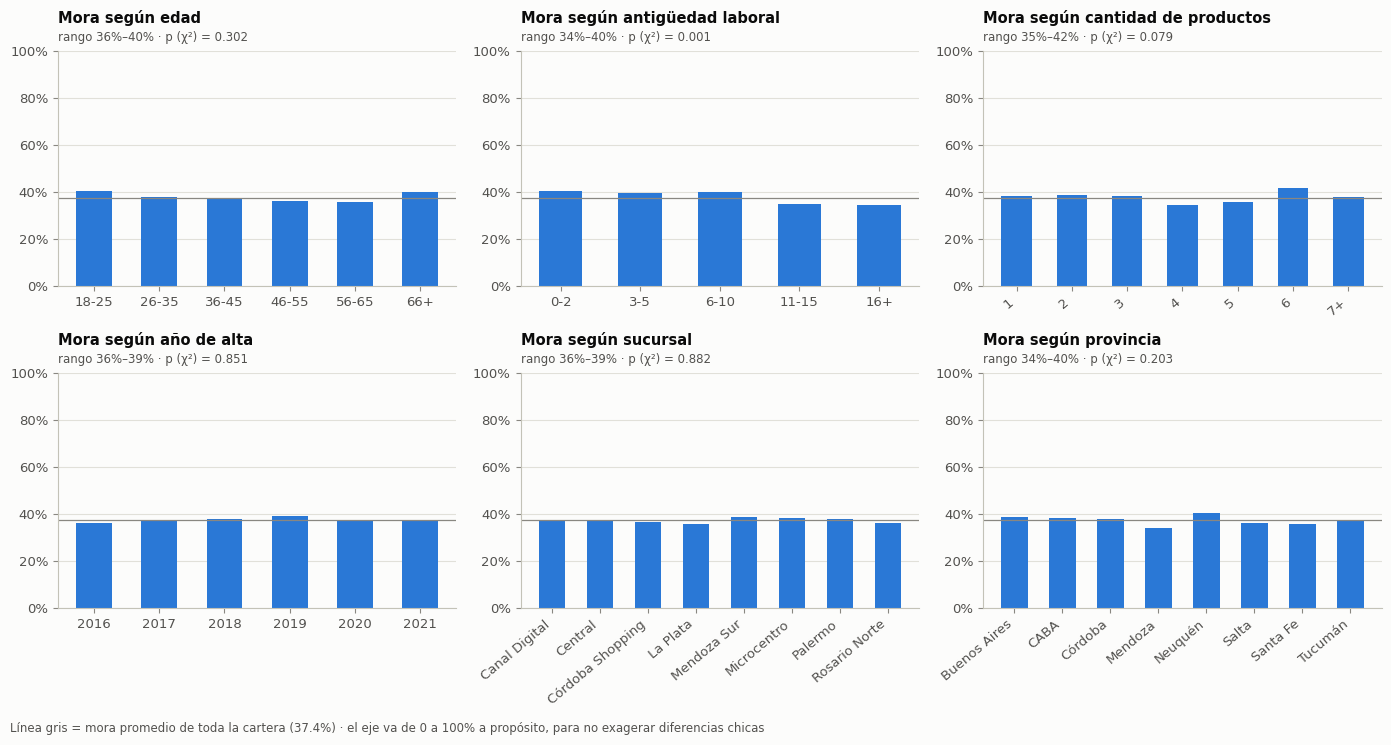

,p-valor χ² (vs. mora)
Edad,0.302
Antigüedad laboral,0.001
Cantidad de productos,0.079
Año de alta,0.851
Sucursal,0.882
Provincia,0.203


In [17]:
bins_edad = pd.cut(df.edad, [17, 25, 35, 45, 55, 65, 80], labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"])
bins_ant = pd.cut(df.antiguedad_imputada, [-1, 2, 5, 10, 15, 30], labels=["0-2", "3-5", "6-10", "11-15", "16+"])
plano = [("Edad", bins_edad), ("Antigüedad laboral", bins_ant), ("Cantidad de productos", df.cant_productos.clip(upper=7)),
         ("Año de alta", df.anio_alta), ("Sucursal", df.sucursal), ("Provincia", df.provincia)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.4)); ax = axes.ravel()
pvals = {}
for a, (n, clave) in zip(ax, plano):
    t = df.groupby(clave, observed=True).mora_historica.mean() * 100
    p = chi2_contingency(pd.crosstab(clave, df.mora_historica))[1]; pvals[n] = p
    etiquetas = [str(i) if not (n == "Cantidad de productos" and i == 7) else "7+" for i in t.index]
    b = a.bar(etiquetas, t.values, color=BLUE, width=0.55)
    a.axhline(tasa_global, color=MUTED, lw=0.9)
    a.set_ylim(0, 100); a.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    if len(etiquetas) > 6: plt.setp(a.get_xticklabels(), rotation=40, ha="right")
    tit(a, f"Mora según {n.lower()}", f"rango {t.min():.0f}%–{t.max():.0f}% · p (χ²) = {p:.3f}")
fig.text(0.01, 0.005, f"Línea gris = mora promedio de toda la cartera ({tasa_global:.1f}%) · el eje va de 0 a 100% a propósito, para no exagerar diferencias chicas", fontsize=8.5, color=INK2)
plt.tight_layout(rect=(0, 0.02, 1, 1)); plt.show()
pd.Series(pvals, name="p-valor χ² (vs. mora)").round(3).to_frame()

Edad (p = 0,30), año de alta (0,85), sucursal (0,88) y provincia (0,20) no muestran asociación con la mora, que se mantiene entre 34% y 41% en todas sus categorías. Cantidad de productos tampoco (p = 0,079; rango de 35% a 42% sin patrón claro).

La antigüedad laboral es la única con asociación estadísticamente significativa (p = 0,001), aunque modesta: ~40% de mora con 10 años o menos contra ~34-35% con más de 10. La diferencia se mantiene dentro de cada tipo de empleo (informal 52,8% → 48,2%; monotributo 37,7% → 35,0%; relación de dependencia 33,9% → 31,2%), por lo que no se explica solo por el tipo de empleo.

Sucursal y provincia no se modificaron en la limpieza por falta de información sobre su significado. Que no se asocien con la mora no descarta que se relacionen con ingreso, score o límite, por lo que se los compara con el test de Kruskal-Wallis (no paramétrico, adecuado para variables asimétricas).

In [18]:
tabla = []
for v, nom in [("ingreso_imputado", "ingreso"), ("score_buro", "score"), ("limite_tarjeta", "límite")]:
    for g in ["sucursal", "provincia"]:
        grupos_g = [x[v].dropna() for _, x in df.groupby(g)]
        tabla.append({"variable": nom, "por": g, "p-valor Kruskal": kruskal(*grupos_g).pvalue})
pd.DataFrame(tabla).round(3)

,variable,por,p-valor Kruskal
0,ingreso,sucursal,0.586
1,ingreso,provincia,0.817
2,score,sucursal,0.218
3,score,provincia,0.484
4,límite,sucursal,0.457
5,límite,provincia,0.839


Ningún p-valor es menor a 0,2 (van de 0,22 a 0,84): ni el ingreso, ni el score, ni el límite difieren entre sucursales o provincias. Estas dos variables no aportan información sobre el nivel económico de los clientes ni sobre su comportamiento crediticio, lo que respalda haberlas dejado sin modificar y las convierte en las primeras candidatas a descartar si se modelara.

Score, mora y tipo de empleo: se compara el score medio de los clientes con y sin mora dentro de cada tipo de empleo.

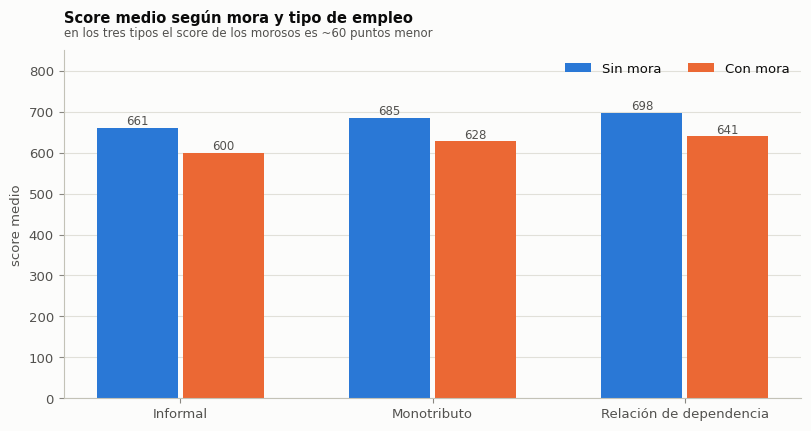

mora_historica,0,1,diferencia
tipo_empleo_imputado,,,
Informal,660.9,599.9,-61.0
Monotributo,684.8,627.9,-56.8
Relación de dependencia,697.9,640.5,-57.3


In [19]:
m = df.groupby(["tipo_empleo_imputado", "mora_historica"]).score_buro.mean().unstack().loc[orden]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
x = np.arange(len(orden)); w = 0.32
b0 = ax.bar(x - w/2 - 0.01, m[0], width=w, color=BLUE, label="Sin mora")
b1 = ax.bar(x + w/2 + 0.01, m[1], width=w, color=ORANGE, label="Con mora")
etiquetas_barras(ax, b0, fmt="{:.0f}"); etiquetas_barras(ax, b1, fmt="{:.0f}")
ax.set_xticks(x); ax.set_xticklabels(orden); ax.set_ylim(0, 850); ax.set_ylabel("score medio")
ax.legend(loc="upper right", ncol=2)
tit(ax, "Score medio según mora y tipo de empleo", "en los tres tipos el score de los morosos es ~60 puntos menor")
plt.tight_layout(); plt.show()
(m.assign(diferencia=lambda t: t[1] - t[0]).round(1))

Los clientes con mora tienen un score entre 57 y 61 puntos menor en los tres tipos de empleo (−61,0 en informales, −56,8 en monotributo y −57,3 en relación de dependencia): la brecha es prácticamente igual en los tres grupos. Entre los clientes sin mora el score sube con la formalidad (661, 685 y 698), lo que indica un efecto propio, pequeño, del tipo de empleo sobre el score.

## 4. Conclusiones generales

**Calidad de datos.** La base quedó en 6.800 clientes únicos y todas las intervenciones son trazables mediante flags: 22 ingresos corregidos por unidad, 1.299 ingresos y 1.332 antigüedades imputados, 530 scores faltantes sin imputar, 320 tipos de empleo asignados y 198 antigüedades dudosas solo marcadas. Los outliers monetarios eran en su gran mayoría la cola natural de distribuciones lognormales, por lo que no se eliminó ningún registro.

**Estructura de la cartera.** Sucursal, provincia y año de alta están balanceados y el 37,4% de los clientes tuvo mora. Las variables monetarias son lognormales y están ligadas al ingreso por reglas de asignación (límite de 0,8 a 2,2 veces el ingreso y préstamo de 1,5 a 8 veces), por lo que los ratios respecto del ingreso son más informativos que los montos absolutos.

**Qué se asocia con la mora.** La asociación es fuerte con el score (74% a 9% entre extremos), deuda/ingreso (19% a 81%), atrasos (31% a 87%), consultas (27% a 71%) e ingreso (61% a 16%); moderada con el tipo de empleo (informales 51%, relación de dependencia 32%); débil con la antigüedad laboral (5 a 6 puntos); y nula con edad, cantidad de productos, año de alta, sucursal y provincia. El score se explica sobre todo por el endeudamiento relativo (Spearman −0,72 con deuda/ingreso), los atrasos y las consultas, y mucho menos por el ingreso o el tipo de empleo. La relación entre deuda/ingreso y mora no es lineal, con un umbral alrededor del quinto decil.

**Para un eventual modelado:**

- Usar escala logarítmica en las variables monetarias y ratios (deuda/ingreso, consumo/límite) en lugar de montos absolutos.
- Cuidar la multicolinealidad del bloque ingreso-límite-préstamo-consumo-saldo (correlaciones de 0,64 a 0,93).
- Incorporar las flags como variables o evaluar la sensibilidad excluyendo los registros imputados.
- Dejar en segundo plano sucursal, provincia, edad, año de alta y cantidad de productos.
- Verificar que score, atrasos y consultas no incorporen información posterior a la mora.

**Limitaciones.** Ingreso y antigüedad tienen ~19% de valores modelados; los ratios se calcularon solo con ingreso observado (n = 5.501), pero las correlaciones de la matriz incluyen valores imputados. El score está censurado en 850 y faltan 530 registros (7,8%). Todos los resultados son asociaciones, no efectos causales.